In [1]:
import os

In [2]:
proxy = "http://cache.ha.univ-nantes.fr:3128/"

os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [3]:
import pandas as pd
import seaborn as sns
import json
import matplotlib.pyplot as plt

In [4]:
with open("../data/json/metrics.json","r" , encoding='utf-8') as file:
    metrics = json.load(file)
metrics = pd.DataFrame(metrics)
idx_drop = metrics[ ((metrics["Licence"] =="CC BY-SA 4.0")&(metrics["Domaine"]=="CHEMICAL"))].index
metrics = metrics.drop(idx_drop).reset_index(drop=True)
metrics.drop(columns=['Doi', 'Auteur', 'Date de publication', 'URL', 'Licence',
                      'Domaine','URL / PDF', 'Sous-domaine'], inplace=True)

In [5]:
with open("../data/json/llm_judgment3.json","r" , encoding='utf-8') as file:
    llmj = json.load(file)
llmj = pd.DataFrame(llmj)
llmj = llmj.drop(idx_drop).reset_index(drop=True)

In [6]:
data = pd.concat([metrics, llmj],axis=1)

In [7]:
facts = pd.read_csv("../data/json/factscores.csv").drop(columns=["FactScore1",
                                                                 "FactScore2","FactScore3"])
facts = facts.drop(idx_drop).reset_index(drop=True)

data = pd.concat([data, facts], axis=1)

In [8]:
sem_cols  = [col for col in data.columns if col.startswith(("Be","Ba","Co", "sem"))]
fact_cols = [col for col in data.columns if col.startswith(("Fa","Cosi","NL", "Na","fa"))]
gen_stats = data.describe()

In [9]:
gen_stats[sem_cols]

,BertScore1,BartScore1,Cos_Sim1,BertScore2,BartScore2,Cos_Sim2,BertScore3,BartScore3,Cos_Sim3,sem_score1,sem_score2,sem_score3,Cosine1,Cosine2,Cosine3
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.794413,-3.142863,0.683440,0.901564,-1.240972,0.770894,0.896939,-1.298309,0.819574,4.833333,4.666667,4.783333,0.315381,0.484787,0.490957
std,0.062122,1.687567,0.165819,0.049712,0.946833,0.154817,0.049859,0.816695,0.163498,0.584582,0.863191,0.413701,0.377348,0.436742,0.424286
min,0.583140,-10.101562,0.355860,0.757488,-6.128906,0.260750,0.753697,-6.394531,0.353878,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000
25%,0.745858,-3.870117,0.535766,0.878465,-1.345947,0.679353,0.867376,-1.646729,0.715674,5.000000,5.000000,5.000000,0.000000,0.000000,0.000000
50%,0.790116,-2.615234,0.679627,0.916527,-0.988037,0.777465,0.899333,-1.132812,0.836990,5.000000,5.000000,5.000000,0.101010,0.500000,0.500000
75%,0.838269,-1.927002,0.823535,0.937660,-0.731079,0.878557,0.933312,-0.787476,0.971434,5.000000,5.000000,5.000000,0.637987,1.000000,0.990625
max,0.927934,-1.011719,0.982824,0.991675,-0.157593,0.996623,0.994604,-0.177734,0.999413,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000


In [10]:
gen_stats[fact_cols]

,FactCC1,FactAcc1,FactScore1,FactCC2,FactAcc2,FactScore2,FactCC3,FactAcc3,FactScore3,fact_score1,...,fact_score3,Naive1,Naive2,Naive3,Cosine1,Cosine2,Cosine3,NLI1,NLI2,NLI3
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,...,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.616667,0.321255,0.140307,0.283333,0.763609,0.270563,0.350000,0.697697,0.247577,4.341667,...,4.758333,0.296255,0.523534,0.511083,0.315381,0.484787,0.490957,0.029967,0.114832,0.078614
std,0.488237,0.284169,0.332874,0.452506,0.335263,0.407342,0.478969,0.338346,0.413908,0.715916,...,0.518495,0.341256,0.419682,0.427680,0.377348,0.436742,0.424286,0.437225,0.523062,0.555861
min,0.000000,0.000000,-0.600000,0.000000,0.000000,-0.600000,0.000000,0.000000,-0.600000,1.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.500000,0.000000,4.000000,...,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.166667,0.000000,-0.025000
50%,1.000000,0.261364,0.000000,0.000000,1.000000,0.120000,0.000000,0.800000,0.078095,4.000000,...,5.000000,0.154762,0.600000,0.555556,0.101010,0.500000,0.500000,0.000000,0.000000,0.000000
75%,1.000000,0.500000,0.239286,1.000000,1.000000,0.596250,1.000000,1.000000,0.581458,5.000000,...,5.000000,0.547980,1.000000,1.000000,0.637987,1.000000,0.990625,0.000000,0.444444,0.458333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,...,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
cr =  data[sem_cols].corr()

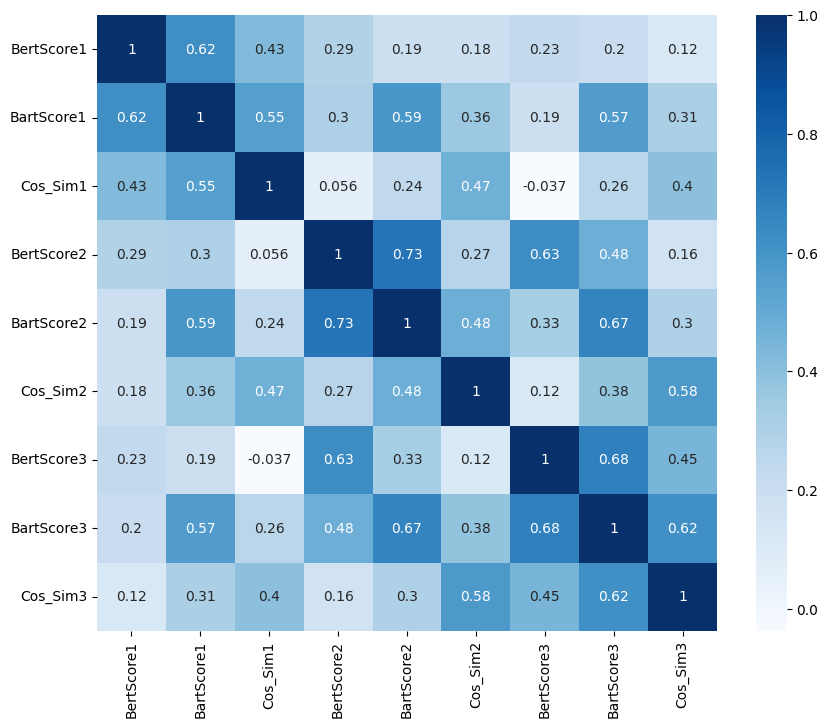

In [12]:
plt.figure(figsize=(10, 8)) 
sns.heatmap(cr.iloc[:9,:9],cmap="Blues", annot=True)
plt.savefig("../figures/cors.png", dpi=300, bbox_inches="tight")

In [13]:
def plot_metric_variations(data, metric_name, save_path=None, *vline):
    """
    Plots boxplots comparing metric variations across rewrites (1, 2, 3)
    for each domain.

    Parameters:
    - data: DataFrame containing columns like Metric1, Metric2, Metric3
    - metric_name: str (e.g., "BertScore", "FactScore", "CosSim")
    - vline: float (optional thresholds to draw vertical line)
    - save_path: url to save graphic
    """
    save_path += (metric_name+".png") 
    cols = [f"{metric_name}1", f"{metric_name}2", f"{metric_name}3"]

    df_long = data.melt(
        id_vars=["Domaine"],
        value_vars=cols,
        var_name="Version",
        value_name=metric_name
    )

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df_long,
        y="Domaine",
        x=metric_name,
        hue="Version"
    )
    if vline:
        for val in vline:
            plt.axvline(x=val, linestyle="--", linewidth=1.5)
            # 🔹 label optionnel (propre pour un papier)
            plt.text(val, (plt.ylim()[1])/2, f"{val}", rotation=0, va='bottom', fontsize=10)

    plt.title(f"Comparison of {metric_name} across rewrites")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

### Analyse générale

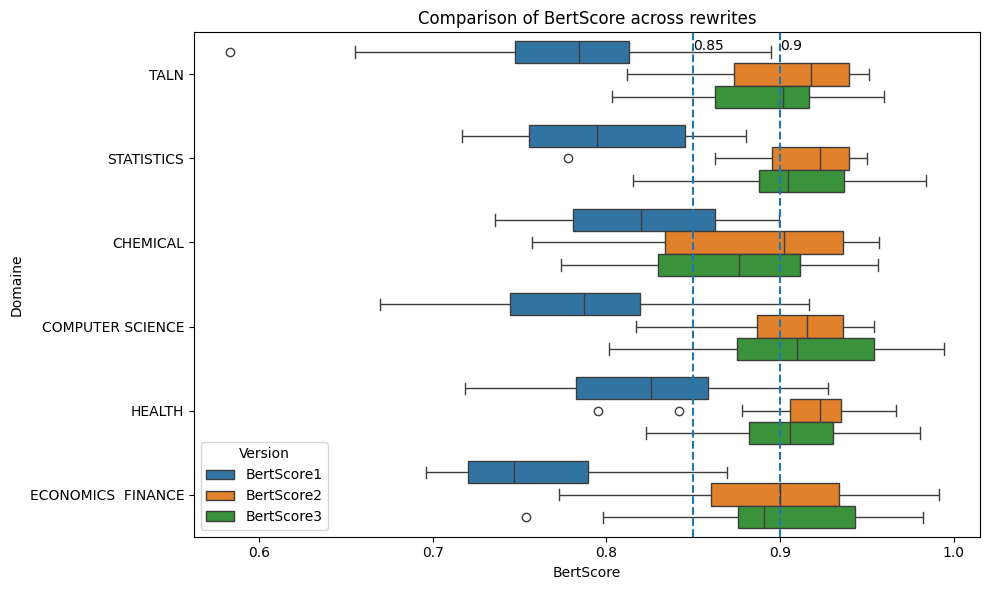

In [14]:
fig_path = "../figures/"
plot_metric_variations(data, "BertScore",fig_path, 0.85,0.9)

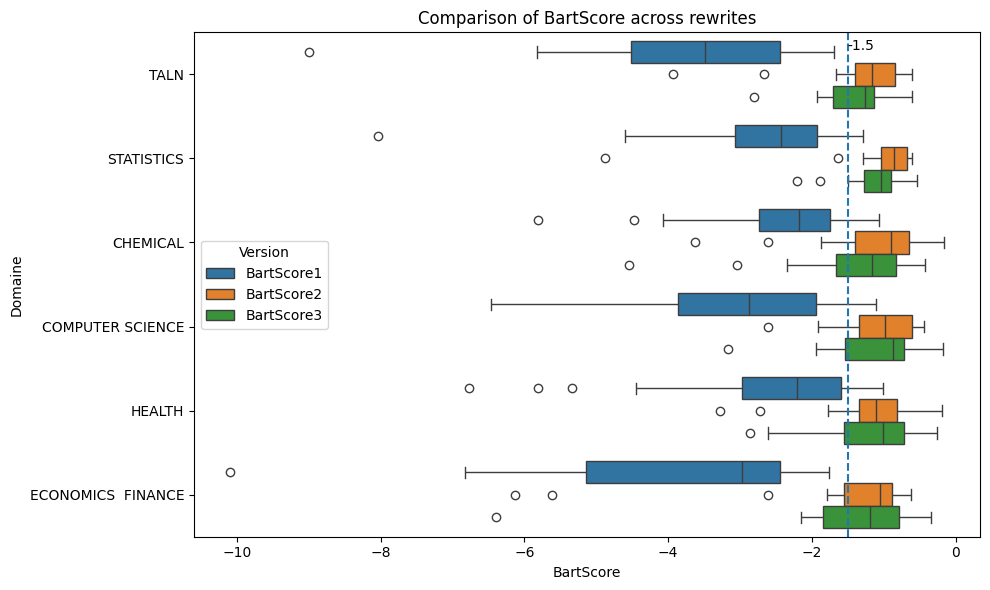

In [15]:
plot_metric_variations(data, "BartScore", fig_path, -1.5)

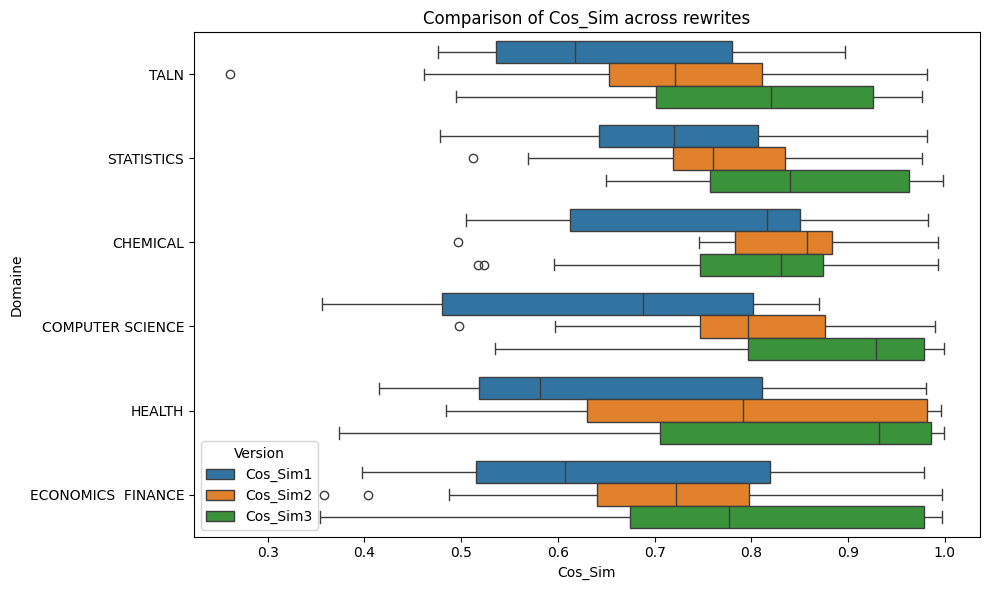

In [16]:
plot_metric_variations(data, "Cos_Sim", fig_path)

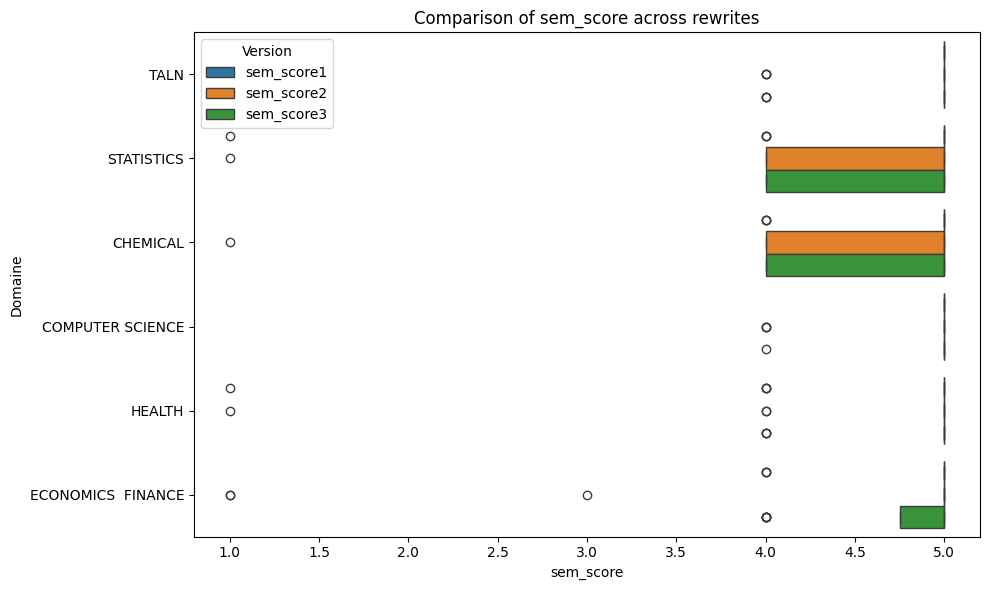

In [17]:
plot_metric_variations(data, "sem_score", fig_path)

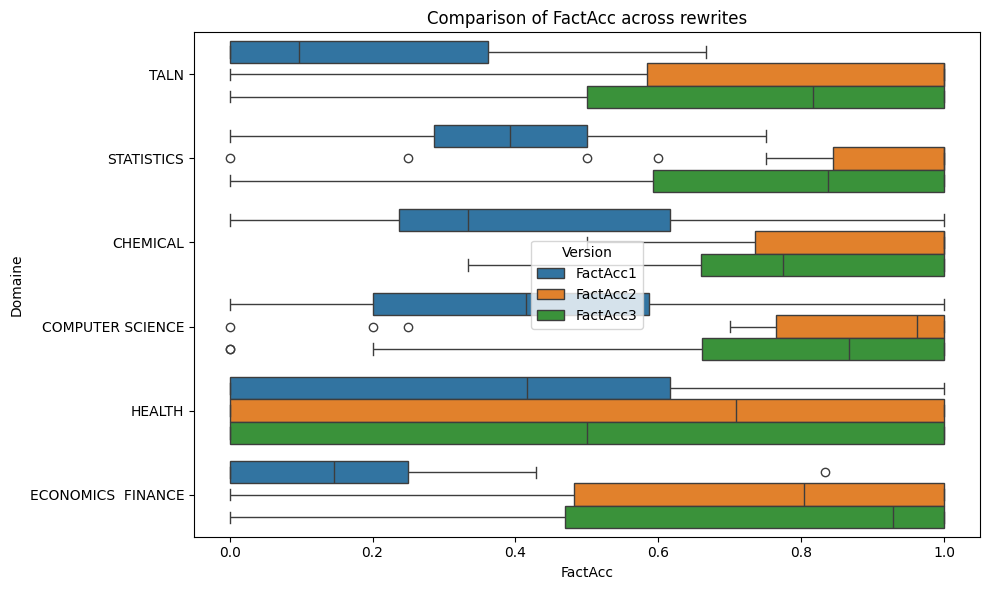

In [18]:
plot_metric_variations(data, "FactAcc", fig_path)

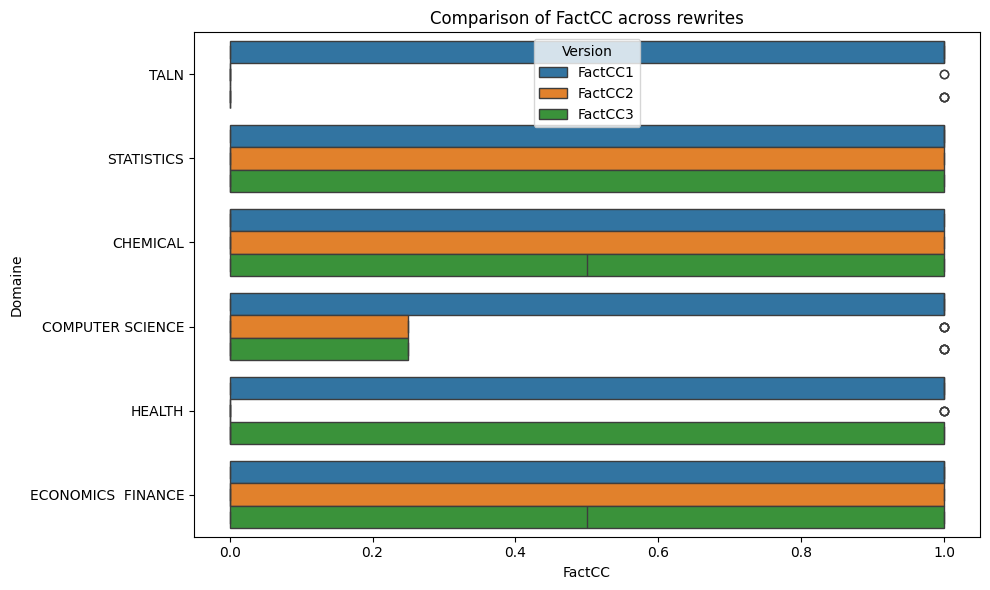

In [19]:
plot_metric_variations(data, "FactCC", fig_path)

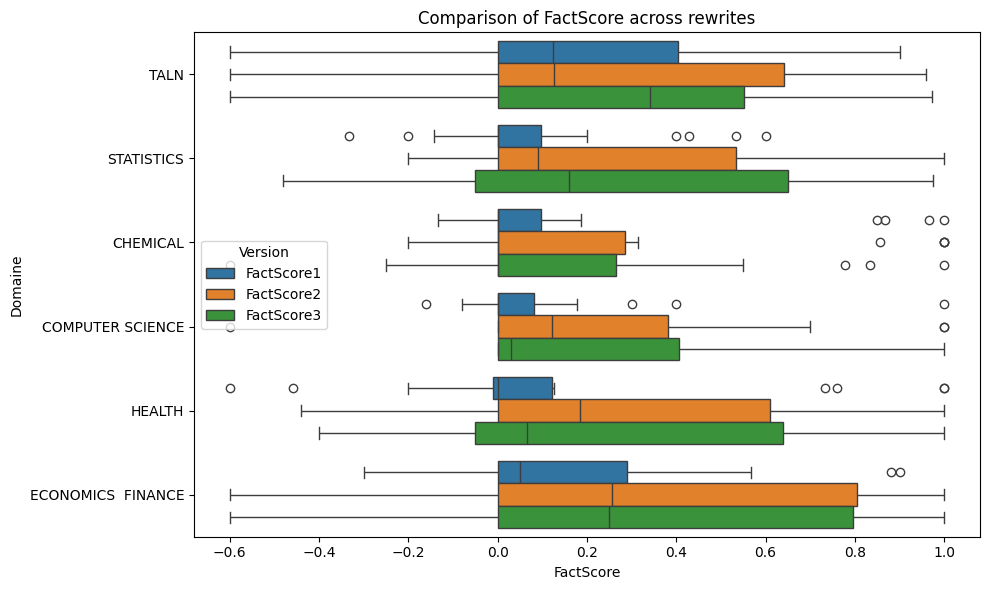

In [20]:
plot_metric_variations(data, "FactScore", fig_path)

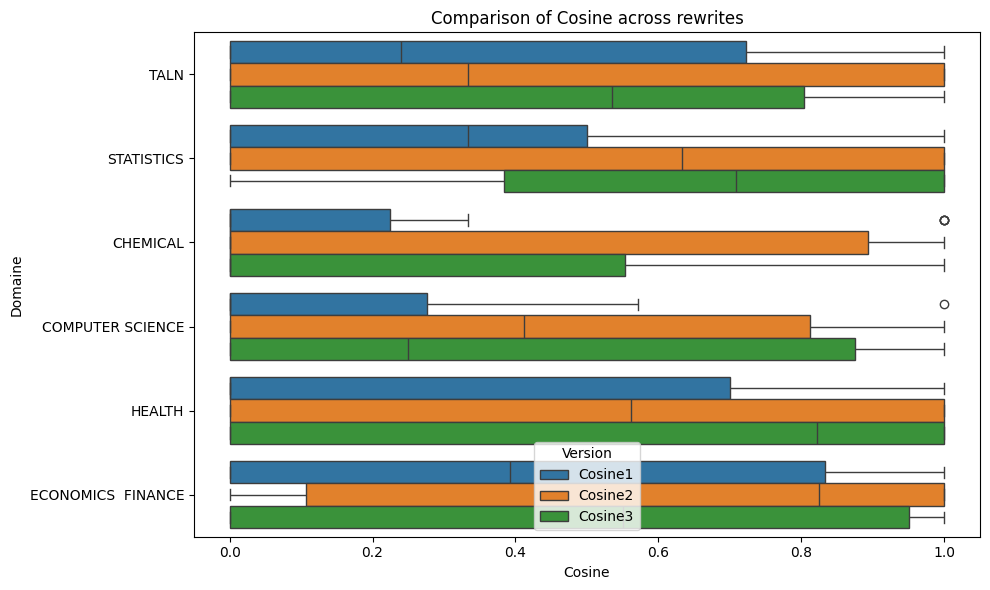

In [21]:
plot_metric_variations(data, "Cosine", fig_path)

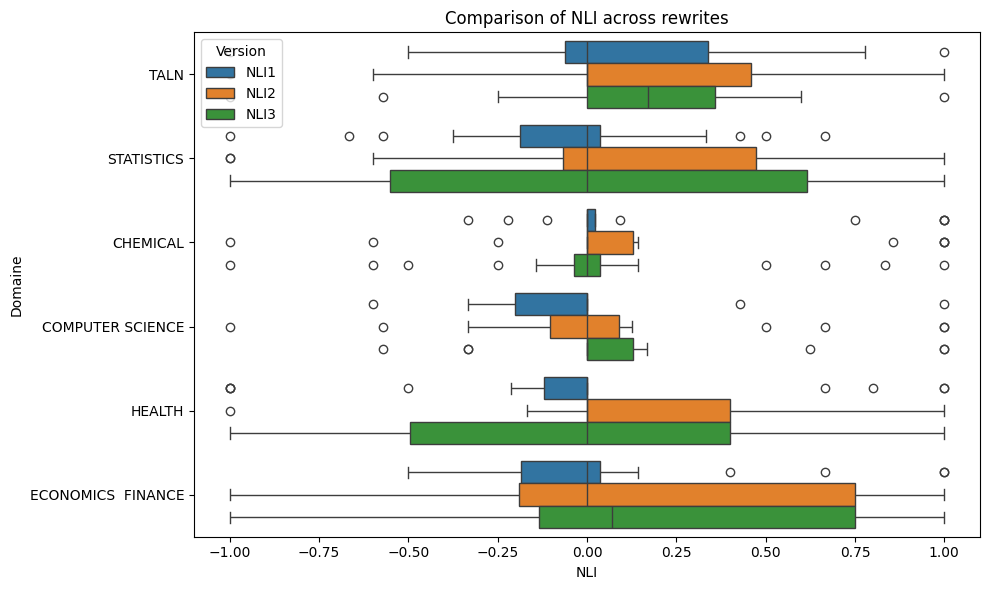

In [22]:
plot_metric_variations(data, "NLI", fig_path)

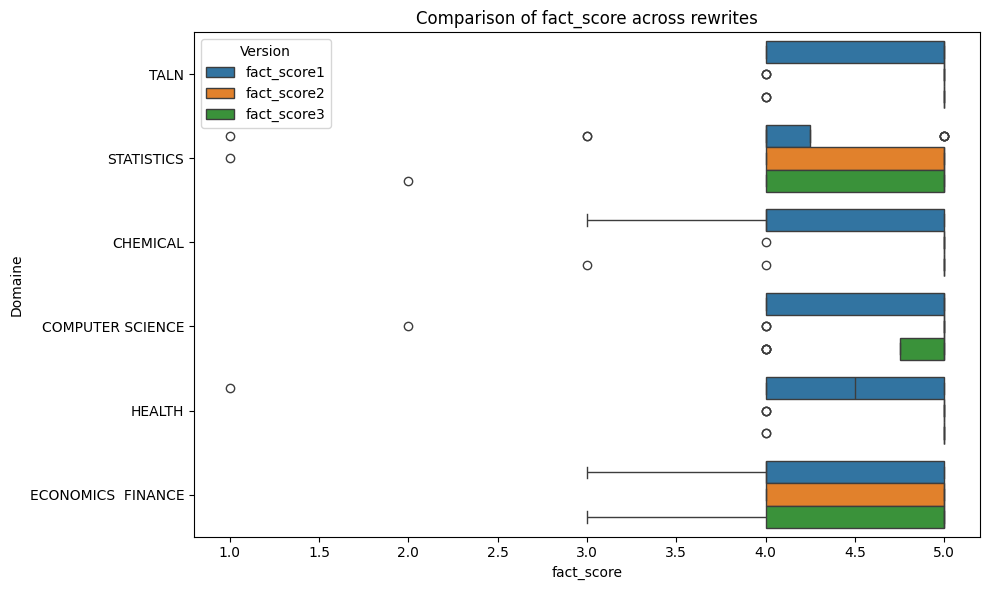

In [23]:
plot_metric_variations(data, "fact_score", fig_path)

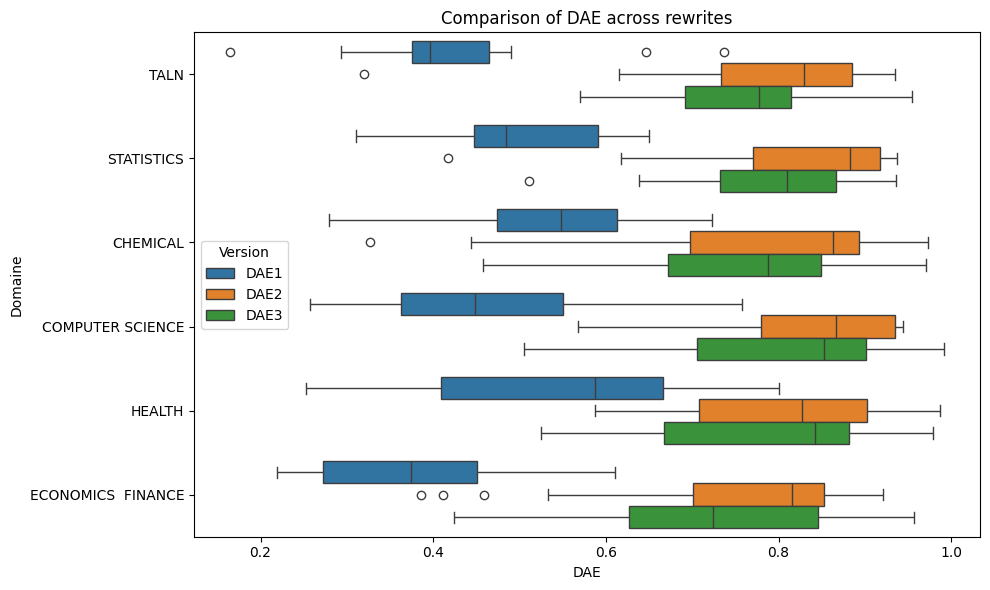

In [24]:
plot_metric_variations(data, "DAE", fig_path)